In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
                             classification_report,roc_auc_score)

# Regression Metrics
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

In [ ]:
df = pd.read_csv("student_placement.csv")

df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,7.97
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,0.00
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,7.65
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,1,7.00
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,0,0.00


In [ ]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (100000, 18)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cgpa,100000.0,7.206381,0.925235,4.0,6.58,7.21,7.83,10.00
backlogs,100000.0,0.547010,0.862727,0.0,0.00,0.00,1.00,3.00
coding_skills,100000.0,5.995147,1.496302,1.0,5.00,6.00,7.00,10.00
dsa_score,100000.0,5.500711,1.781961,1.0,4.30,5.50,6.70,10.00
aptitude_score,100000.0,64.990511,11.990892,20.0,56.80,65.00,73.10,100.00
communication_skills,100000.0,5.990614,1.496552,1.0,5.00,6.00,7.00,10.00
ml_knowledge,100000.0,4.508752,1.968278,0.0,3.20,4.50,5.90,10.00
system_design,100000.0,4.008210,1.778405,0.0,2.80,4.00,5.20,10.00
internships,100000.0,1.095040,0.940264,0.0,0.00,1.00,2.00,3.00
projects_count,100000.0,2.397280,1.242829,0.0,1.00,2.00,3.00,5.00


In [ ]:
print(df.isnull().sum())

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64


In [ ]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


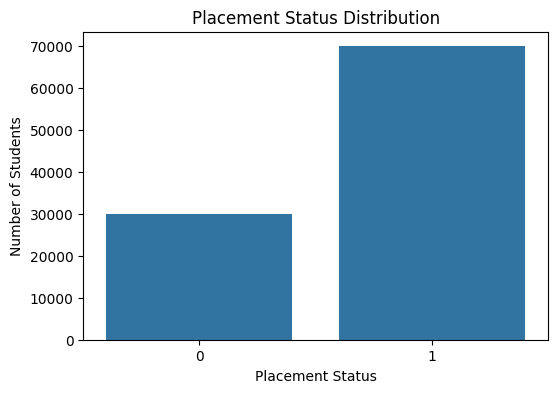

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="placement_status")

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

/tmp/ipykernel_710/3452936999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="placement_status",y="cgpa",palette="Blues")


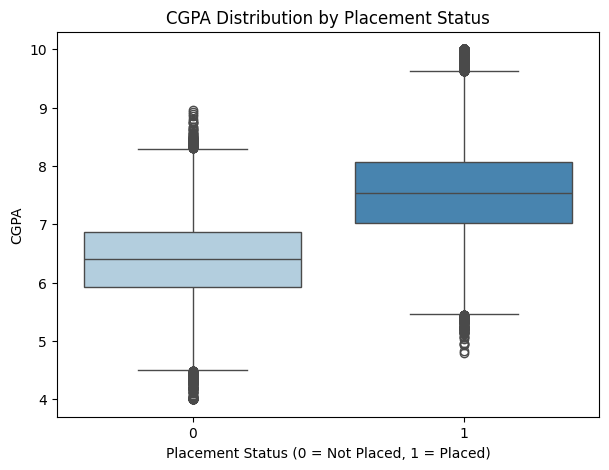

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df,x="placement_status",y="cgpa",palette="Blues")

plt.title("CGPA Distribution by Placement Status")
plt.xlabel("Placement Status (0 = Not Placed, 1 = Placed)")
plt.ylabel("CGPA")

plt.show()

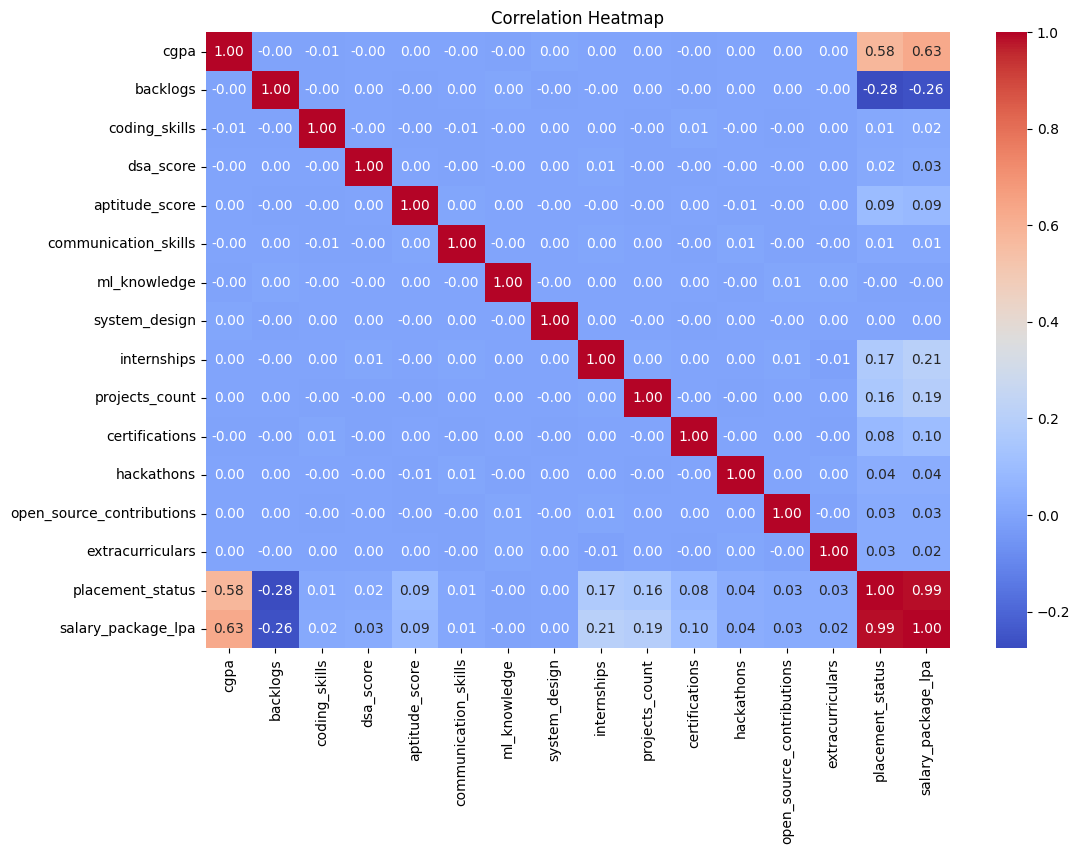

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

## **Data Preprocessing**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Branch Encoder
le_branch = LabelEncoder()
df["branch"] = le_branch.fit_transform(df["branch"])

# College Tier Encoder
le_tier = LabelEncoder()
df["college_tier"] = le_tier.fit_transform(df["college_tier"])

In [ ]:
X = df.drop(["placement_status", "salary_package_lpa"], axis=1)

y = df["placement_status"]

In [ ]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (100000, 16)
Target Shape : (100000,)


## **Horizontal Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (80000, 16)
Testing Data : (20000, 16)


## **Standard Scaling**

In [ ]:
scaler_cls = StandardScaler()

X_train = scaler_cls.fit_transform(X_train)

X_test = scaler_cls.transform(X_test)

## **Logistic Regression**

"Logistic Regression is a simple and widely used classification algorithm. Since our target variable, placement_status, has only two classes (Placed and Not Placed), Logistic Regression is a suitable baseline model."

In [ ]:
# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8843
Precision : 0.9044168872788073
Recall : 0.9323470267164607
F1 Score : 0.9181696018105948


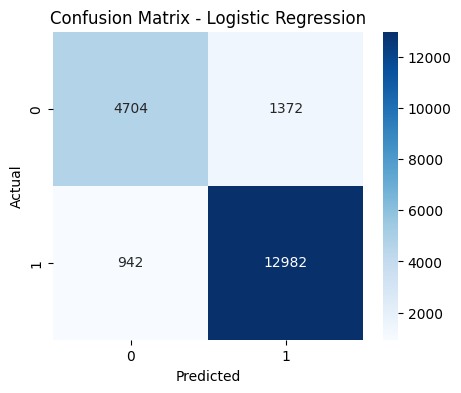

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80      6076
           1       0.90      0.93      0.92     13924

    accuracy                           0.88     20000
   macro avg       0.87      0.85      0.86     20000
weighted avg       0.88      0.88      0.88     20000



## **Decision Tree Classifier**

"Decision Tree classifies data by repeatedly splitting it based on the most important features until a prediction is reached. It is easy to understand and visualize."

In [ ]:
from sklearn.model_selection import GridSearchCV
dt_params = {"max_depth": [5, 10, 15],"min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4]}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid=dt_params,cv=5,scoring="accuracy",n_jobs=-1)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

In [ ]:
print("Best Decision Tree Parameters:")
print(grid_dt.best_params_)

Best Decision Tree Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.86105
Precision : 0.8878140441227643
Recall : 0.9161878770468256
F1 Score : 0.9017778249036864


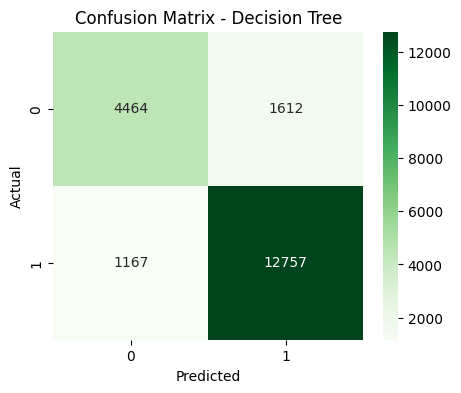

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.79      0.73      0.76      6076
           1       0.89      0.92      0.90     13924

    accuracy                           0.86     20000
   macro avg       0.84      0.83      0.83     20000
weighted avg       0.86      0.86      0.86     20000



## **Random Forest Classifier**

In [ ]:
# Create the model
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.877
Precision : 0.8969529085872576
Recall : 0.9301924734271761
F1 Score : 0.9132703426879143


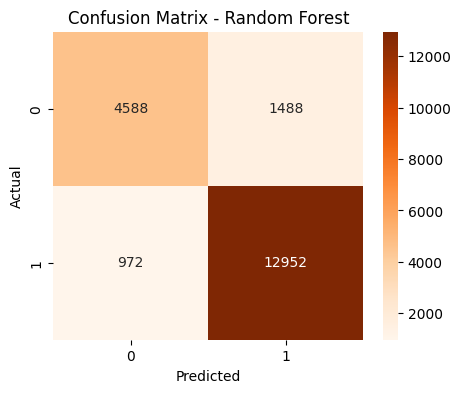

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79      6076
           1       0.90      0.93      0.91     13924

    accuracy                           0.88     20000
   macro avg       0.86      0.84      0.85     20000
weighted avg       0.88      0.88      0.88     20000



In [ ]:
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr),accuracy_score(y_test, y_pred_dt),accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_lr),precision_score(y_test, y_pred_dt),precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_lr),recall_score(y_test, y_pred_dt),recall_score(y_test, y_pred_rf)],
    "F1 Score": [f1_score(y_test, y_pred_lr),f1_score(y_test, y_pred_dt),f1_score(y_test, y_pred_rf)]})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.88430,0.904417,0.932347,0.918170
1,Decision Tree,0.86105,0.887814,0.916188,0.901778
2,Random Forest,0.87700,0.896953,0.930192,0.913270


In [ ]:
classification_results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.88430,0.904417,0.932347,0.918170
2,Random Forest,0.87700,0.896953,0.930192,0.913270
1,Decision Tree,0.86105,0.887814,0.916188,0.901778


## Classification Conclusion

Three classification models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.

Among them, Logistic Regression achieved the highest accuracy of **88.43%**, making it the best-performing model for predicting student placement. Random Forest and Decision Tree also produced strong results with accuracies above 86%.

The results indicate that features such as CGPA, internships, projects, and academic performance play an important role in predicting placement outcomes.

# **Salary Prediction using Regression**

In [ ]:
placed_df = df[df["placement_status"] == 1]

placed_df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,3,2,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,7.97
2,4,1,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,7.65
3,0,1,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,1,7.00
5,1,2,6.21,1,6.7,6.5,69.9,5.0,4.0,5.2,2,3,3,2,0,1,1,7.33
6,1,2,7.91,0,7.0,3.9,61.5,6.7,4.9,2.2,2,5,2,1,0,3,1,8.31


In [ ]:
print("Placed Students :", placed_df.shape)

Placed Students : (70000, 18)


**Vertical Split**

In [ ]:
y_reg = placed_df["salary_package_lpa"]
X_reg = placed_df.drop(["placement_status", "salary_package_lpa"],axis=1)

**Horizontal Split**

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)

**Standard Scaling**

In [ ]:
scaler_reg = StandardScaler()

X_train_reg = scaler_reg.fit_transform(X_train_reg)

X_test_reg = scaler_reg.transform(X_test_reg)

# **Linear Regression**

In [ ]:
lr_reg = LinearRegression()

lr_reg.fit(X_train_reg, y_train_reg)

y_pred_lr_reg = lr_reg.predict(X_test_reg)

In [ ]:
print("MAE :", mean_absolute_error(y_test_reg, y_pred_lr_reg))

print("MSE :", mean_squared_error(y_test_reg, y_pred_lr_reg))

print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)))

print("R2 Score :", r2_score(y_test_reg, y_pred_lr_reg))

MAE : 0.3211639004480031
MSE : 0.16199173601112904
RMSE : 0.40248196979632395
R2 Score : 0.5862829742801241


# **Decision Tree Regressor**

In [ ]:
dt_reg = DecisionTreeRegressor(max_depth=10,min_samples_split=10,min_samples_leaf=5,random_state=42)

dt_reg.fit(X_train_reg, y_train_reg)

y_pred_dt_reg = dt_reg.predict(X_test_reg)

In [ ]:
print("MAE :", mean_absolute_error(y_test_reg, y_pred_dt_reg))

print("MSE :", mean_squared_error(y_test_reg, y_pred_dt_reg))

print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_dt_reg)))

print("R2 Score :", r2_score(y_test_reg, y_pred_dt_reg))

MAE : 0.34372147246915424
MSE : 0.18536675647046227
RMSE : 0.4305423979940446
R2 Score : 0.5265845959633919


# **Random Forest Regressor**

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=200,max_depth=15,min_samples_split=5,min_samples_leaf=2,random_state=42)

rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test_reg)

In [ ]:
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf_reg))

print("MSE :", mean_squared_error(y_test_reg, y_pred_rf_reg))

print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)))

print("R2 Score :", r2_score(y_test_reg, y_pred_rf_reg))

MAE : 0.3306995073504046
MSE : 0.17164680274719032
RMSE : 0.41430279114096047
R2 Score : 0.5616245219940411


# **Regression Model Comparision**

In [ ]:
regression_results = pd.DataFrame({

    "Model":["Linear Regression","Decision Tree","Random Forest"],

    "MAE":[mean_absolute_error(y_test_reg,y_pred_lr_reg),mean_absolute_error(y_test_reg,y_pred_dt_reg),mean_absolute_error(y_test_reg,y_pred_rf_reg)],

    "RMSE":[np.sqrt(mean_squared_error(y_test_reg,y_pred_lr_reg)),np.sqrt(mean_squared_error(y_test_reg,y_pred_dt_reg)),np.sqrt(mean_squared_error(y_test_reg,y_pred_rf_reg))],

    "R2 Score":[r2_score(y_test_reg,y_pred_lr_reg),r2_score(y_test_reg,y_pred_dt_reg),r2_score(y_test_reg,y_pred_rf_reg)]})

regression_results.round(4)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.3212,0.4025,0.5863
1,Decision Tree,0.3437,0.4305,0.5266
2,Random Forest,0.3307,0.4143,0.5616


**Regression Conclusion**

Linear Regression achieved the highest R² score (0.5863) and the lowest prediction errors, making it the most suitable model for predicting salary packages. Decision Tree and Random Forest also produced satisfactory results, demonstrating that the selected features have a meaningful relationship with salary.

In [ ]:
regression_results.sort_values(by="R2 Score",ascending=False)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.321164,0.402482,0.586283
2,Random Forest,0.330700,0.414303,0.561625
1,Decision Tree,0.343721,0.430542,0.526585


In [ ]:
importance_reg = pd.DataFrame({"Feature":X_reg.columns,"Importance":rf_reg.feature_importances_})

importance_reg = importance_reg.sort_values(by="Importance",ascending=False)

importance_reg

,Feature,Importance
2,cgpa,0.404149
10,internships,0.147303
11,projects_count,0.132352
5,dsa_score,0.041652
4,coding_skills,0.040948
12,certifications,0.040377
6,aptitude_score,0.038837
8,ml_knowledge,0.034960
9,system_design,0.033619
7,communication_skills,0.033461


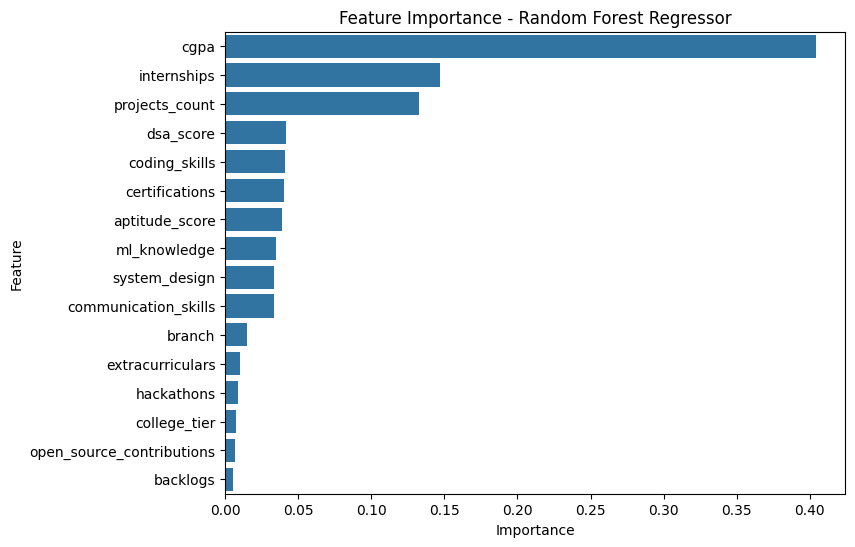

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(data=importance_reg,x="Importance",y="Feature")

plt.title("Feature Importance - Random Forest Regressor")

plt.show()

In [ ]:
import joblib

# Save Classification Model
joblib.dump(lr_model, "placement_model.pkl")

# Save Regression Model
joblib.dump(lr_reg, "salary_model.pkl")

# Save Scaler
joblib.dump(scaler_cls, "classification_scaler.pkl")
joblib.dump(scaler_reg, "regression_scaler.pkl")

['regression_scaler.pkl']

In [ ]:
import joblib

joblib.dump(le_branch, "branch_encoder.pkl")
joblib.dump(le_tier, "tier_encoder.pkl")

['tier_encoder.pkl']

In [ ]:
from google.colab import files

#files.download("placement_model.pkl")
#files.download("salary_model.pkl")
#files.download("classification_scaler.pkl")
#files.download("regression_scaler.pkl")
#files.download("branch_encoder.pkl")
#files.download("tier_encoder.pkl")